# Transformation to C Code (Simple)

## Imports

In [1]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np

from zoomy_jax.fvm.solver_jax import Settings
from zoomy_core.model.models.shallow_water import ShallowWaterEquations

import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
from zoomy_core.misc.misc import Zstruct
import zoomy_core.misc.misc as misc
from zoomy_core.transformation.to_amrex import AmrexModel

## Model definition

In [2]:
bcs = BC.BoundaryConditions(
    [
        BC.Wall(tag="top"),
        BC.Wall(tag="bottom"),
        BC.Wall(tag="left"),
        BC.Wall(tag="right"),
    ]
)

def custom_ic(x):
    Q = np.zeros(3, dtype=float)
    Q[0] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

model = ShallowWaterEquations(
    dimension=2,
    boundary_conditions=bcs,
    initial_conditions=ic,
)



## Sympy Model

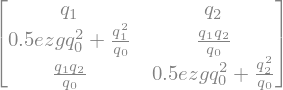

In [3]:
model.flux()

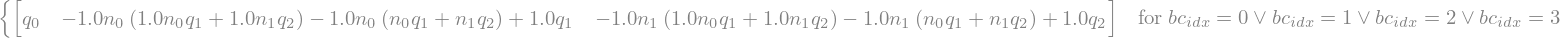

In [4]:
model.print_boundary_conditions()

## Code transformation

In [5]:
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/trafo", filename="swe.h5"))
AmrexModel.write_code(model, settings)

2026-01-10 11:32:12.455 | WARNING  | zoomy_core.misc.misc:__init__:194 - No 'clean_directory' attribute found in output Zstruct. Default: False
2026-01-10 11:32:12.457 | WARNING  | zoomy_core.misc.misc:__init__:197 - No 'snapshots' attribute found in output Zstruct. Default: 2


'/home/ingo/Git/Zoomy/outputs/trafo/.amrex_interface/Model.H'

## Check the output

In [6]:
main_dir = misc.get_main_directory()
path = os.path.join(main_dir, os.path.join(settings.output.directory, '.amrex_interface/Model.H'))
with open(path, "r") as f:
    print(f.read())


#pragma once
#include <AMReX_Array4.H>
#include <AMReX_Vector.H>
#include <AMReX_SmallMatrix.H>
#include <vector>
#include <string>


struct Model {

    // --- Constants ---
    static constexpr int n_dof_q    = 3;
    static constexpr int n_dof_qaux = 2;
    static constexpr int dimension  = 2;
    static constexpr int n_boundary_tags = 4;

    // --- Helpers ---
    static const std::vector<std::string> get_boundary_tags() { return { "bottom", "left", "right", "top" }; }

    // --- Kernels ---

    AMREX_GPU_HOST_DEVICE AMREX_FORCE_INLINE
    static amrex::SmallMatrix<amrex::Real,3,2> flux(
        amrex::SmallMatrix<amrex::Real,3,1> const& Q,
        amrex::SmallMatrix<amrex::Real,2,1> const& Qaux) noexcept
    {
        auto res = amrex::SmallMatrix<amrex::Real,3,2>{};
    amrex::Real t0 = 0.5*1.0*9.81*amrex::Math::powi<2>(Q(0));
    amrex::Real t1 = (1.0 / amrex::Math::powi<1>(Q(0)));
    amrex::Real t2 = Q(1)*Q(2)*t1;
    res(0,0) = Q(1);
    res(0,1) = Q(2);
    res(1,0) = amr